Script to produce plots for single vortex rings for thesis chapter 5. These will be compared to the plots using the averaged results later on.

The plots needed here are:
* line plots of velocity and vorticity
* contours of flow field
* quiver plots
* stream plots

Boilerplate code

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sys
import os
import h5py
import matplotlib.colors as colors
import matplotlib.cm

#####Import Ollie Tools
dirPath = "C:/Coding"
sys.path.insert(0, dirPath)
import OllieTools as oj
print(dirPath)


####Import Ollie Tools MAC
# dirPath = "/Users/olliejackson/Coding"
# sys.path.insert(0, dirPath)
# import OllieTools as oj
# print(dirPath)

oj.thesis_plot_settings()

C:/Coding/Code
C:/Coding


Loading in the ring, scaling, and calculating variables from it.

In [7]:
dir = 'G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/'

u, v = oj.importData73(str(dir) + "3/Data/PIV_export_fine.mat")
u, v = oj.scaleVelNozzle(u, v, 90)
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])

Time = oj.frames_to_seconds(u, v, 90)
vort, vort_gauss = oj.calculate_vorticity(u, v)

Filtered Data Imported  -  (2699, 149, 239)


Contour of flow field plots
* u
* v
* $\omega$

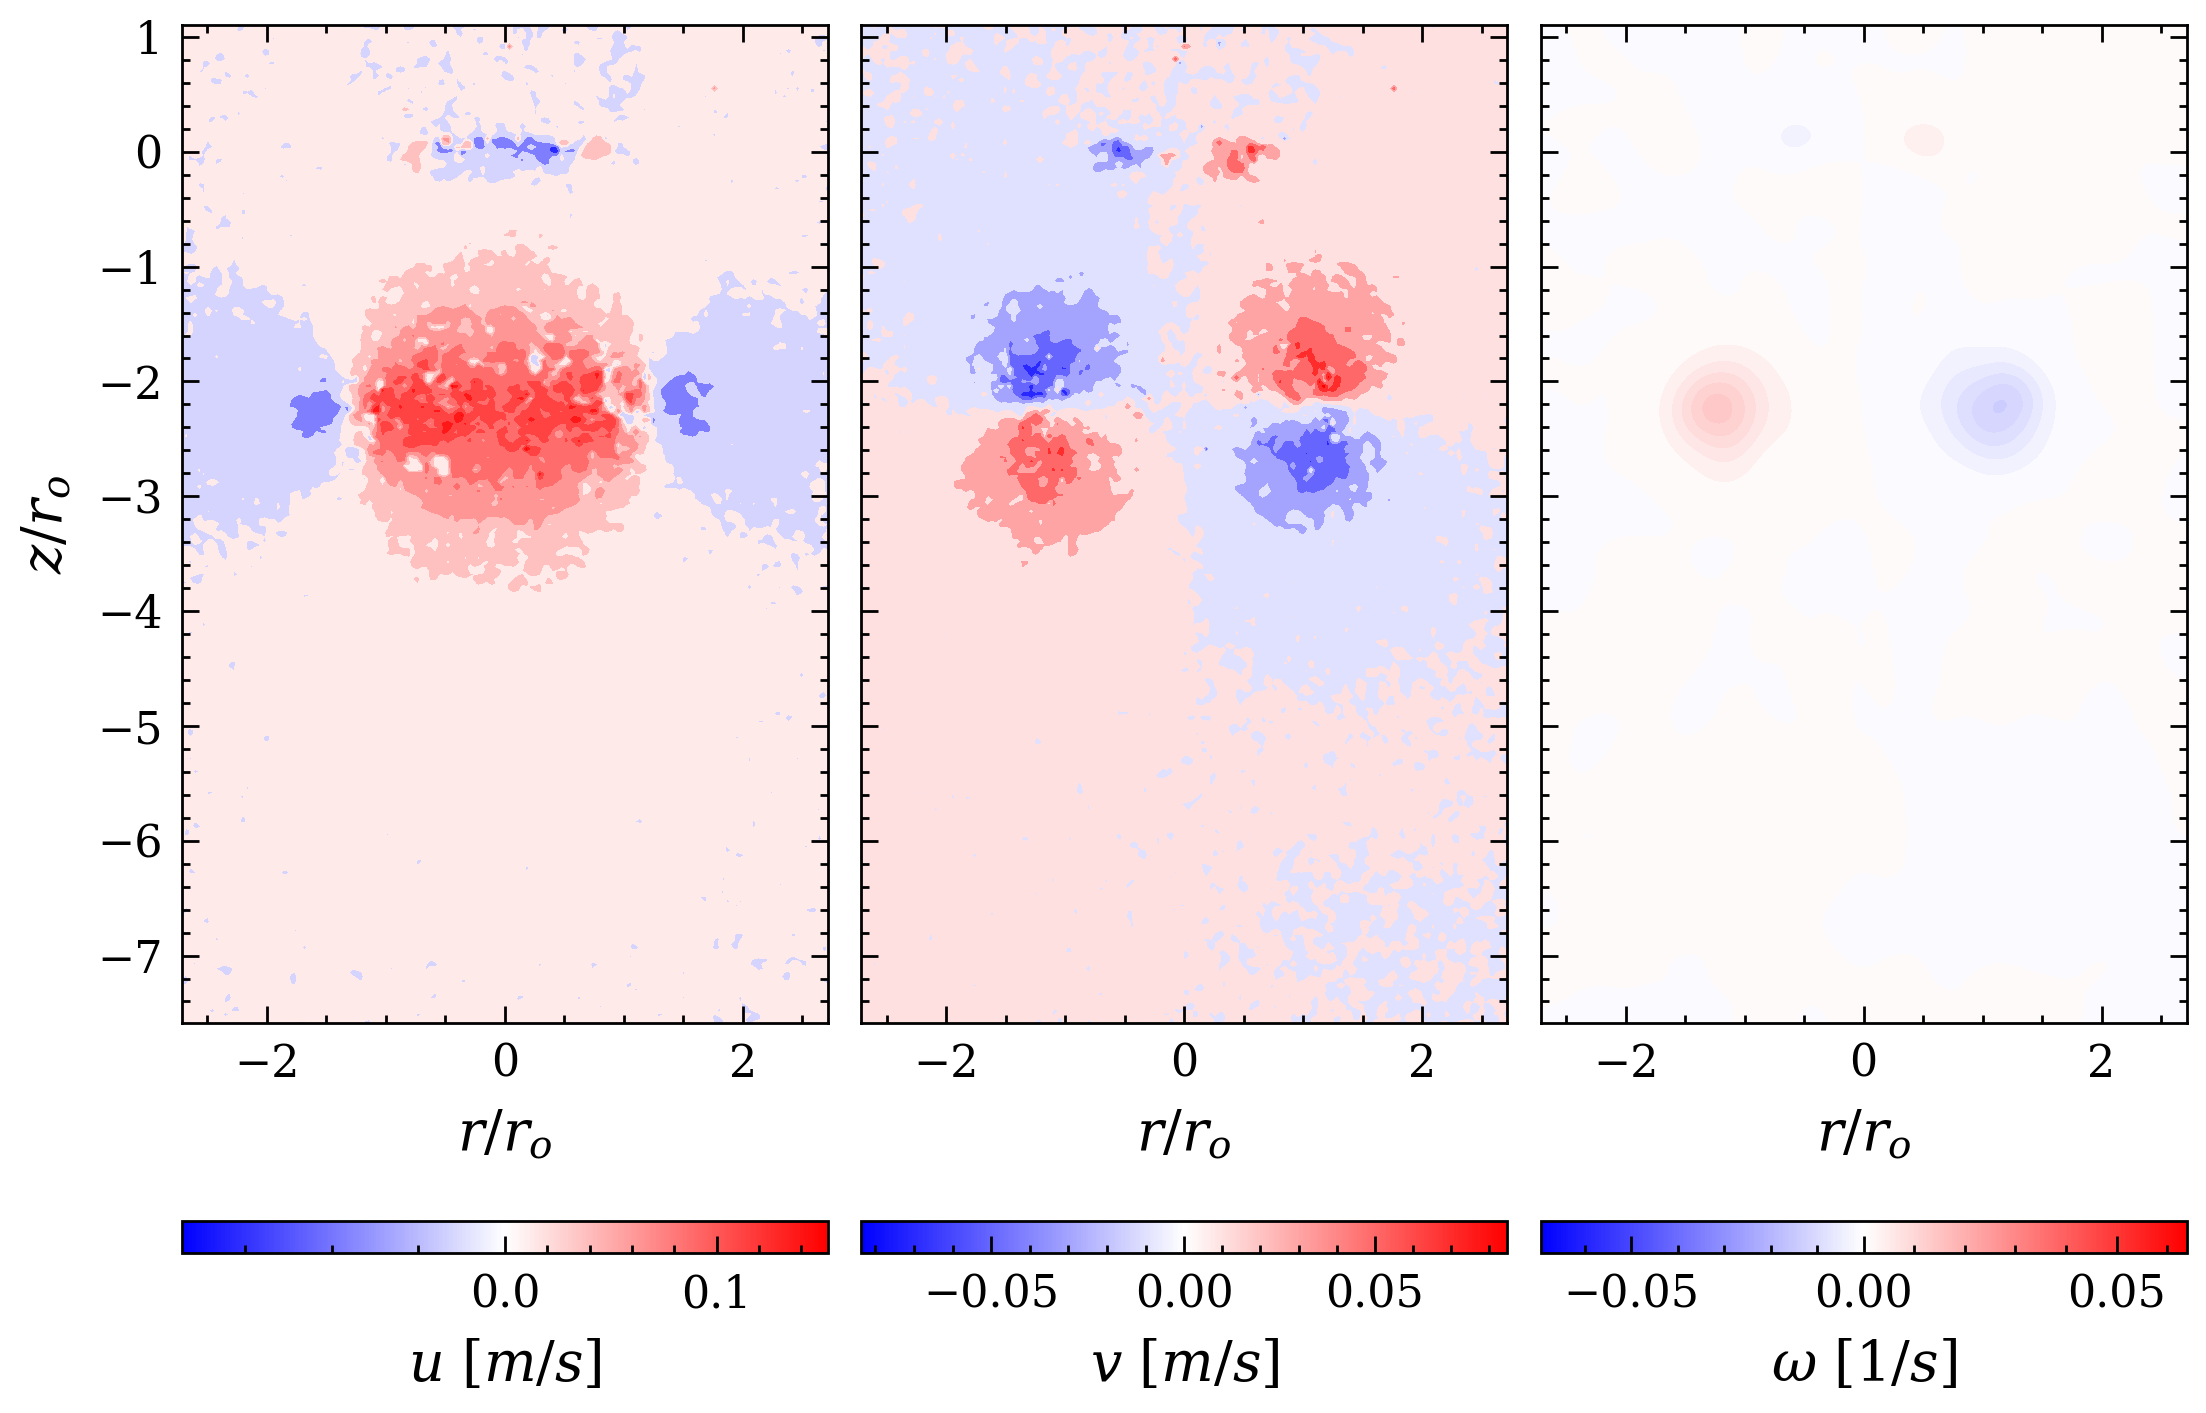

In [14]:
# norm = colors.TwoSlopeNorm(vmin=np.min(u[300, :, :]), vcenter=0, vmax=np.max(u[300, :, :]))
# fig, ax = plt.subplots(1, 1)
# ax.contourf(r_nd, -z_nd, np.rot90(u[300, :, :], 3), norm=norm, cmap='bwr', levels=10)
# fig.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap='bwr'), ax=ax, label=r'$u$' )
# plt.show()

unorm = colors.TwoSlopeNorm(vmin=np.min(u[300, :, :]), vcenter=0, vmax=np.max(u[300, :, :]))
vnorm = colors.TwoSlopeNorm(vmin=np.min(v[300, :, :]), vcenter=0, vmax=np.max(v[300, :, :]))
onorm = colors.TwoSlopeNorm(vmin=np.min(vort[300, :, :]), vcenter=0, vmax=np.max(vort[300, :, :]))


f1, axs = plt.subplots(1, 3, figsize=(5.5, 3.5), layout='constrained')
axs[0].contourf(r_nd, -z_nd, np.rot90(u[300, :, :], 3), norm=unorm, cmap='bwr', levels=10)
axs[0].set_xlabel(r"$r/r_{o}$")
axs[0].set_ylabel(r"$z/r_{o}$")
f1.colorbar(matplotlib.cm.ScalarMappable(norm=unorm, cmap='bwr'), ax=axs[0], label=r'$u ~[m/s]$', location='bottom')
axs[1].contourf(r_nd, -z_nd, np.rot90(v[300, :, :], 3), norm=vnorm, cmap='bwr', levels=10)
axs[1].set_xlabel(r"$r/r_{o}$")
axs[1].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=vnorm, cmap='bwr'), ax=axs[1], label=r'$v ~[m/s]$', location='bottom')
axs[2].contourf(r_nd, -z_nd, np.rot90(vort_gauss[300, :, :], 3), norm=onorm, cmap='bwr', levels=10)
axs[2].set_xlabel(r"$r/r_{o}$")
axs[2].set_yticklabels([])
f1.colorbar(matplotlib.cm.ScalarMappable(norm=onorm, cmap='bwr'), ax=axs[2], label=r'$\omega ~[1/s]$', location='bottom')
plt.show()

Line Plot through the ring at a single time:

Showing:
* u
* v
* $\omega$

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


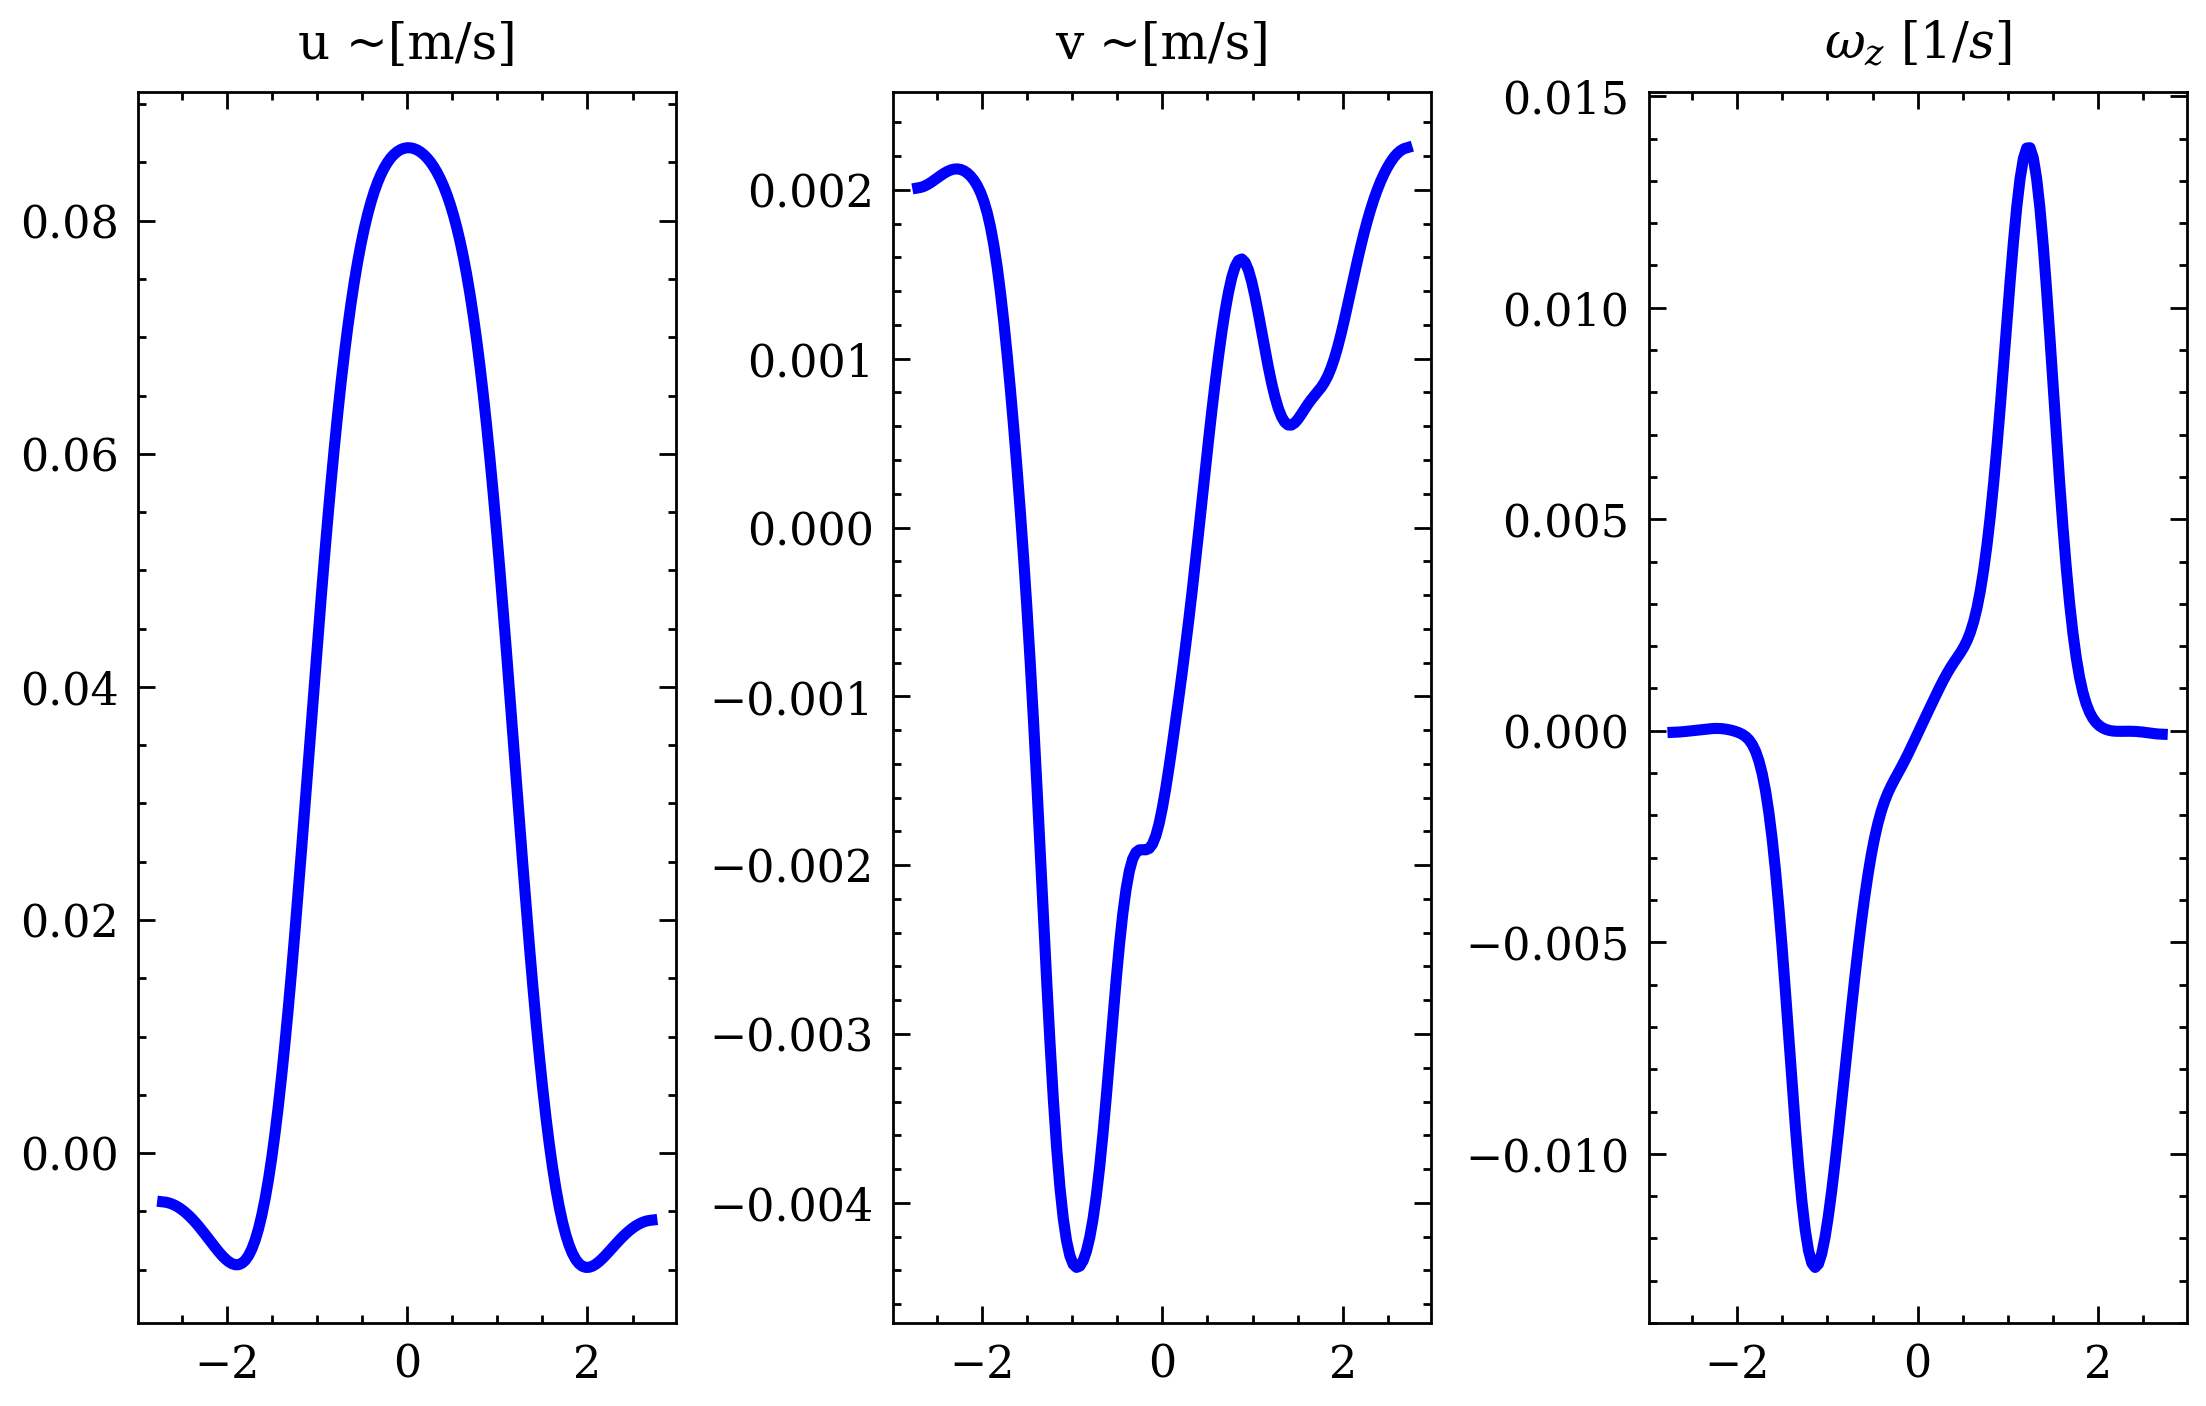

: 

In [ ]:
vort_loc_min, vort_loc_max = oj.vorticityPeakTracking(u, v)

frame = 300

zLocation = int(np.mean([vort_loc_min[frame,1], vort_loc_max[frame,1]], axis=0) )
# print(zLocation)
# print(vort_loc_min[frame,1])
# print(vort_loc_max[frame,1])

# fig, ax = plt.subplots(1, 1)
# ax.plot(vort_loc_max[:,1], label="Max Vorticity")
# ax.plot(vort_loc_min[:,1], label="Min Vorticity")
# ax.set_xlabel("Time (s)")
# ax.set_ylabel("Vorticity (1/s)")
# plt.legend()
# plt.show()
from scipy.ndimage import gaussian_filter
sigma = 5
ugauss, vgauss, vort_gauss = gaussian_filter(u, sigma=10), gaussian_filter(v, sigma=sigma), gaussian_filter(vort, sigma=sigma)


fig, ax = plt.subplots(1, 3, sharex=True, figsize=(5.5, 3.5), layout='constrained')
ax[0].set_title('u ~[m/s]', fontsize=9)
ax[0].plot(r_nd, ugauss   [frame,:,zLocation], color = 'b')
ax[1].set_title('v ~[m/s]', fontsize=9)
ax[1].plot(r_nd, vgauss   [frame,:,zLocation], color = 'b')
ax[2].set_title(r'$\omega_{z} ~[1/s]$', fontsize=9)
ax[2].plot(r_nd, vort_gauss[frame,:,zLocation], color = 'b')
ax[2].legend()
plt.show()

Quiver Plot - need to load in the coarse data for this one

Filtered Data Imported  -  (2699, 69, 111)


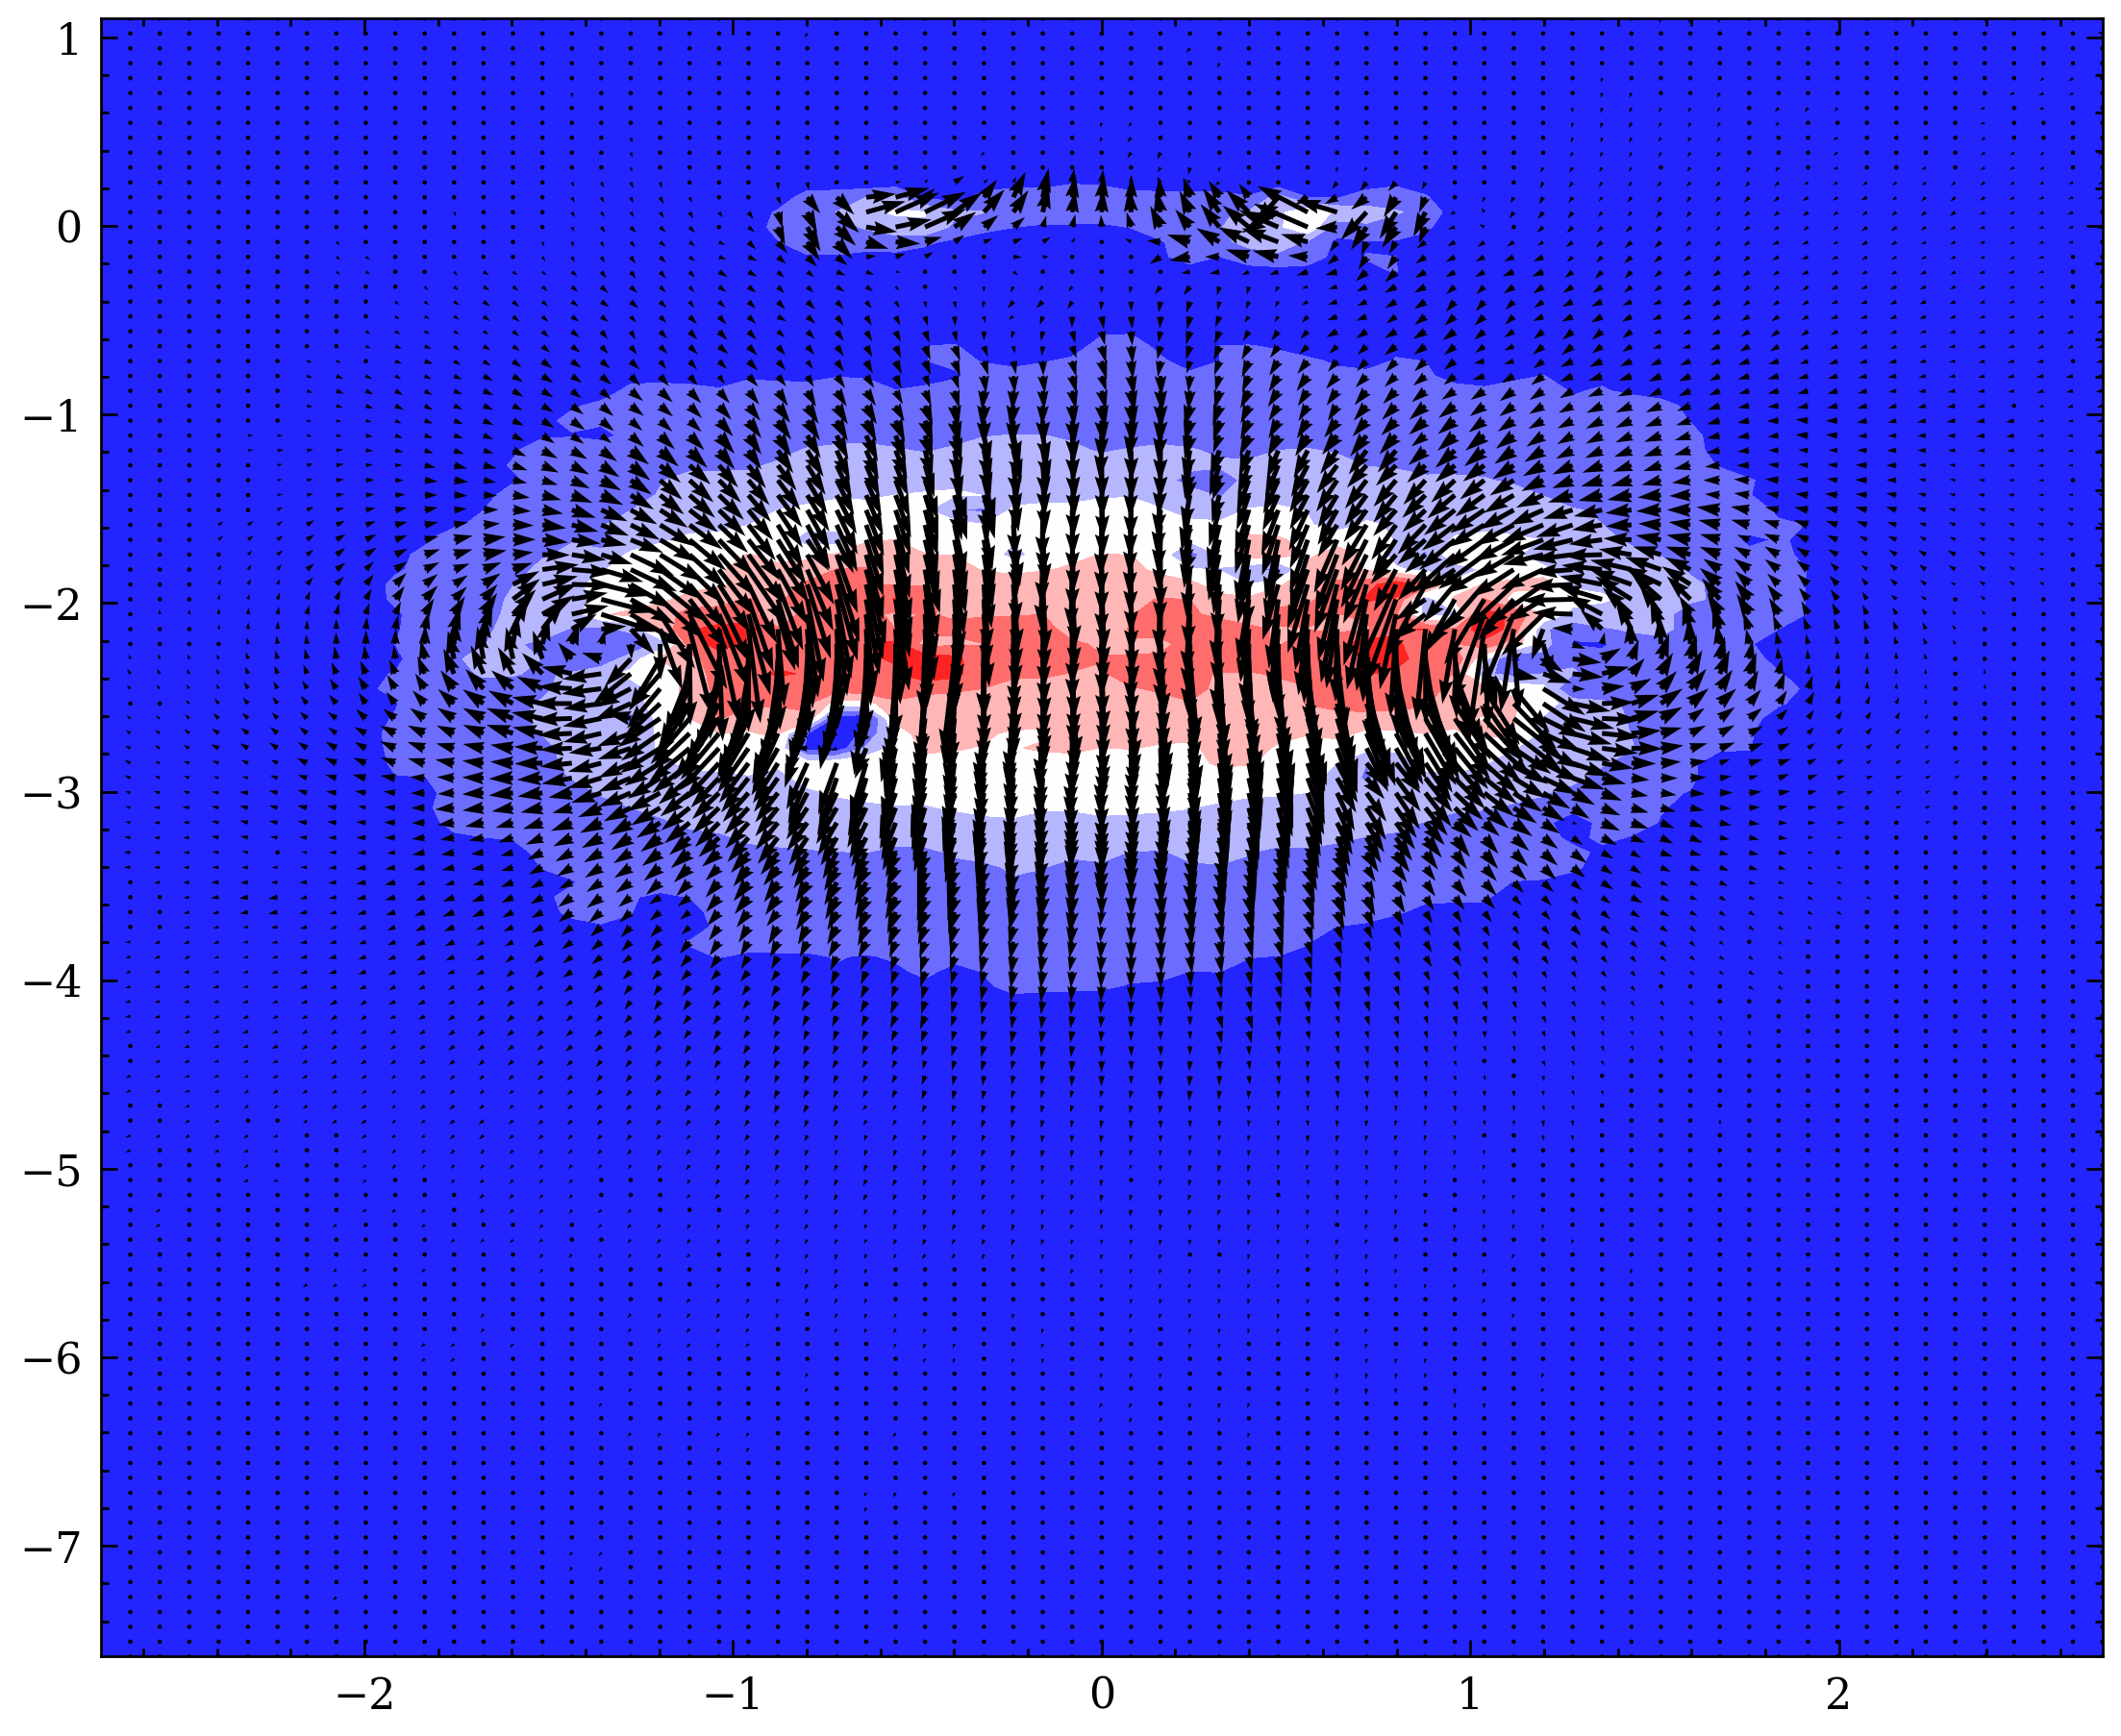

In [5]:
dir = 'G:/Testing/RPM-0.0__Upiston-100__Stroke-100/2023-08-22__FPS-90/'

u, v = oj.importData73(str(dir) + "3/Data/PIV_export.mat")
u, v = oj.scaleVelNozzle(u, v, 90)
r_nd, z_nd = oj.NDUnitsForPlotsNozzle(u.shape[1], u.shape[2])

V = np.sqrt(u**2 + v**2)

fig, ax = plt.subplots(1, 1, sharex=True, figsize=(5.5, 4.5), layout='constrained')
ax.contourf(r_nd, -z_nd, np.rot90(V[frame, :, :], 3), cmap='bwr')
ax.quiver(r_nd, -z_nd, np.rot90(-v[frame, :, :], 3), np.rot90(-u[frame, :, :], 3))
plt.show()